
# Condensed nearest-neighbour


An illustration of the condensed nearest-neighbour method.




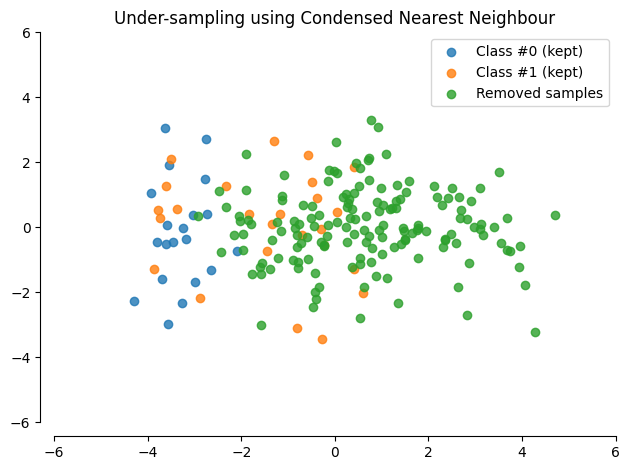

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from imblearn.under_sampling import CondensedNearestNeighbour

# Generate dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.1, 0.9],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=200, random_state=10
)

# PCA for visualization
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# Apply CNN undersampling
cnn = CondensedNearestNeighbour()
X_resampled, y_resampled = cnn.fit_resample(X, y)

# 🔥 ambil indeks sampel yang dipertahankan
idx_resampled = cnn.sample_indices_

# Transform resampled data
X_res_vis = pca.transform(X_resampled)

# Samples removed
idx_samples_removed = np.setdiff1d(np.arange(X_vis.shape[0]), idx_resampled)

# Plot
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

idx_class_0 = y_resampled == 0

plt.scatter(X_res_vis[idx_class_0, 0], X_res_vis[idx_class_0, 1],
            alpha=.8, label='Class #0 (kept)')
plt.scatter(X_res_vis[~idx_class_0, 0], X_res_vis[~idx_class_0, 1],
            alpha=.8, label='Class #1 (kept)')
plt.scatter(X_vis[idx_samples_removed, 0], X_vis[idx_samples_removed, 1],
            alpha=.8, label='Removed samples')

# Make nice plotting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.set_xlim([-6, 6])
ax.set_ylim([-6, 6])

plt.title('Under-sampling using Condensed Nearest Neighbour')
plt.legend()
plt.tight_layout()
plt.show()


# Neighbourhood Cleaning Rule


An illustration of the neighbourhood cleaning rule method.


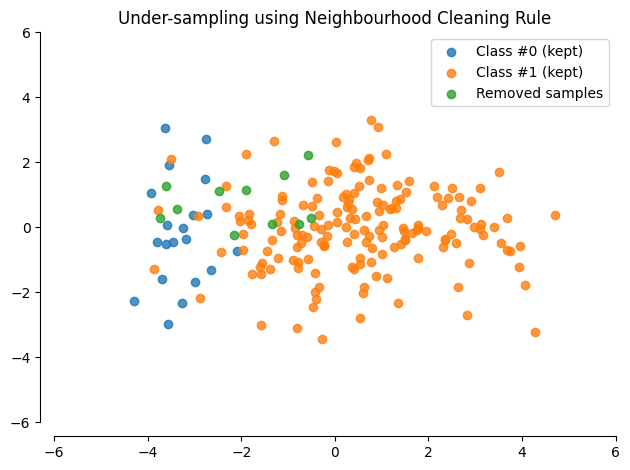

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from imblearn.under_sampling import NeighbourhoodCleaningRule

# Generate dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.1, 0.9],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=200, random_state=10
)

# PCA for visualization
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# Apply Neighbourhood Cleaning Rule
ncl = NeighbourhoodCleaningRule()
X_resampled, y_resampled = ncl.fit_resample(X, y)

# Indices kept
idx_resampled = ncl.sample_indices_

# Transform resampled data
X_res_vis = pca.transform(X_resampled)

# Samples removed
idx_samples_removed = np.setdiff1d(np.arange(X_vis.shape[0]), idx_resampled)

# Plot
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

idx_class_0 = y_resampled == 0

plt.scatter(X_res_vis[idx_class_0, 0], X_res_vis[idx_class_0, 1],
            alpha=.8, label='Class #0 (kept)')
plt.scatter(X_res_vis[~idx_class_0, 0], X_res_vis[~idx_class_0, 1],
            alpha=.8, label='Class #1 (kept)')
plt.scatter(X_vis[idx_samples_removed, 0], X_vis[idx_samples_removed, 1],
            alpha=.8, label='Removed samples')

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.set_xlim([-6, 6])
ax.set_ylim([-6, 6])

plt.title('Under-sampling using Neighbourhood Cleaning Rule')
plt.legend()
plt.tight_layout()
plt.show()

# Nearmiss 1 & 2 & 3

An illustration of the nearmiss 1 & 2 & 3 method.

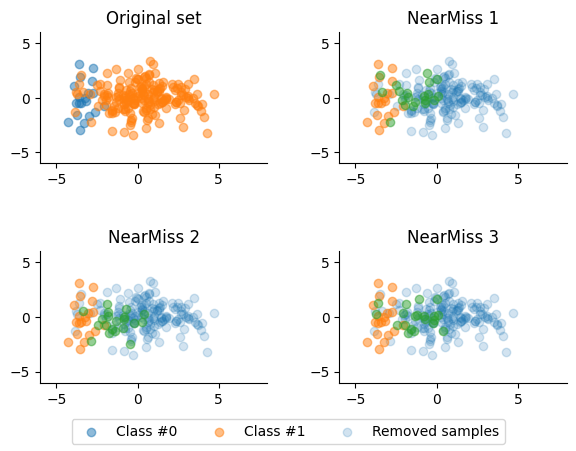

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from imblearn.under_sampling import NearMiss

def plot_resampling(ax, X, y, title):
    c0 = ax.scatter(X[y == 0, 0], X[y == 0, 1], label="Class #0", alpha=0.5)
    c1 = ax.scatter(X[y == 1, 0], X[y == 1, 1], label="Class #1", alpha=0.5)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([-6, 8])
    ax.set_ylim([-6, 6])
    return c0, c1

# Generate dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.1, 0.9],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=200, random_state=10
)

# PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# NearMiss versions
version = [1, 2, 3]
nm = [NearMiss(version=v) for v in version]

X_res_vis = []
y_resampled = []
idx_removed_all = []

for method in nm:
    X_res, y_res = method.fit_resample(X, y)
    idx_res = method.sample_indices_

    X_res_vis.append(pca.transform(X_res))
    y_resampled.append(y_res)

    idx_removed = np.setdiff1d(np.arange(X_vis.shape[0]), idx_res)
    idx_removed_all.append(idx_removed)

# Plot
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax_res = [ax2, ax3, ax4]

c0, c1 = plot_resampling(ax1, X_vis, y, 'Original set')

for i in range(len(version)):
    c3 = ax_res[i].scatter(X_vis[idx_removed_all[i], 0],
                           X_vis[idx_removed_all[i], 1],
                           alpha=.2, label='Removed samples')
    plot_resampling(ax_res[i], X_res_vis[i], y_resampled[i],
                    f'NearMiss {version[i]}')

plt.figlegend((c0, c1, c3), ('Class #0', 'Class #1', 'Removed samples'),
              loc='lower center', ncol=3)
plt.tight_layout(pad=3)
plt.show()